In [3]:
import pandas as pd
from sklearn import linear_model
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_log_error, mean_squared_error, mean_absolute_error

In [4]:
biking_df = pd.read_csv("Bike_hiring.csv")

Analyzing the dataset

In [5]:
biking_df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


Droping unnecessary features

In [6]:
biking_df.drop(["casual", "registered"], axis=1, inplace=True)

Dividing datetime column into useful different features (day, hout, mont, year)
and normalizing ranges of numerical features

In [7]:
#normalization of attributes
biking_df['datetime'] = pd.to_datetime(biking_df['datetime'])

biking_df['hour'] = biking_df['datetime'].dt.hour
biking_df['dayofweek'] = biking_df['datetime'].dt.dayofweek
biking_df['month'] = biking_df['datetime'].dt.month
biking_df['year'] = biking_df['datetime'].dt.year

biking_df['temp'] = biking_df['temp']/10
biking_df['atemp'] = biking_df['atemp']/10
biking_df['humidity'] = biking_df['humidity']/biking_df['humidity'].max()
biking_df['windspeed'] = biking_df['windspeed']/biking_df['windspeed'].max()

In [8]:
biking_df.isnull().sum() #Dataset does not have null elements

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
count         0
hour          0
dayofweek     0
month         0
year          0
dtype: int64

Dividing the dataset into train and test sets with 70%/30% fraction

In [9]:
biking_df_train = biking_df.sample(frac=0.7, random_state=15)
biking_df_test = biking_df.drop(biking_df_train.index)

X_train = biking_df_train.drop(['count', 'datetime'], axis=1)
y_train = biking_df_train['count']

y_train_log = np.log1p(y_train)

X_test = biking_df_test.drop(['count', 'datetime'], axis=1)
y_test = biking_df_test['count']

Creating function for evaluating different models and their metrics

In [10]:
def evaluate_model(name, y_true, y_pred):
    y_true = y_true.clip(0)
    y_pred = y_pred.clip(0)
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred))
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {"model": name, "RMSLE": rmsle, "RMSE": rmse, "MAE": mae}

results = []

training and predicting different models

In [11]:
#Linear Model
lm = linear_model.LinearRegression().fit(X_train,y_train_log)
y_pred_log = lm.predict(X_test)
y_pred_lm = np.expm1(y_pred_log)
results.append(evaluate_model("LinearRegression", y_test, y_pred_lm))

In [12]:
#RandomForest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=1,
    n_jobs=-1
)
rf.fit(X_train, y_train_log)
y_pred_rf = np.expm1(rf.predict(X_test))
results.append(evaluate_model("RandomForest", y_test, y_pred_rf))

In [13]:
#GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=1)
gbr.fit(X_train, y_train_log)
y_pred_gbr = np.expm1(gbr.predict(X_test))
results.append(evaluate_model("GradientBoosting", y_test, y_pred_gbr))

Checking the result

In [14]:
results_df = pd.DataFrame(results)
print(results_df)

              model     RMSLE        RMSE         MAE
0  LinearRegression  1.010358  158.366369  104.209099
1      RandomForest  0.319148   49.366482   29.396461
2  GradientBoosting  0.371465   68.361313   41.150791


Analyzing the importance of features for the models

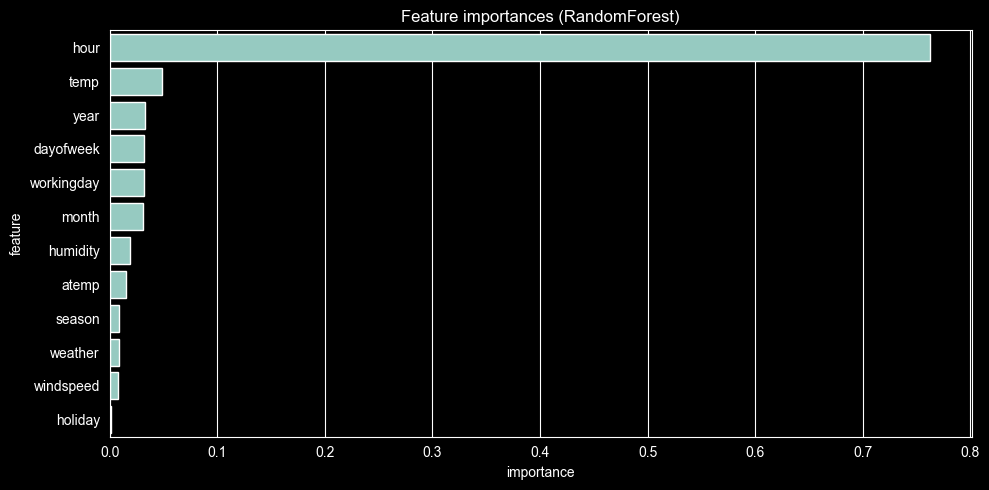

In [15]:
#importance of the features for the RandomForest
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importances, x="importance", y="feature")
plt.title("Feature importances (RandomForest)")
plt.tight_layout()
plt.show()

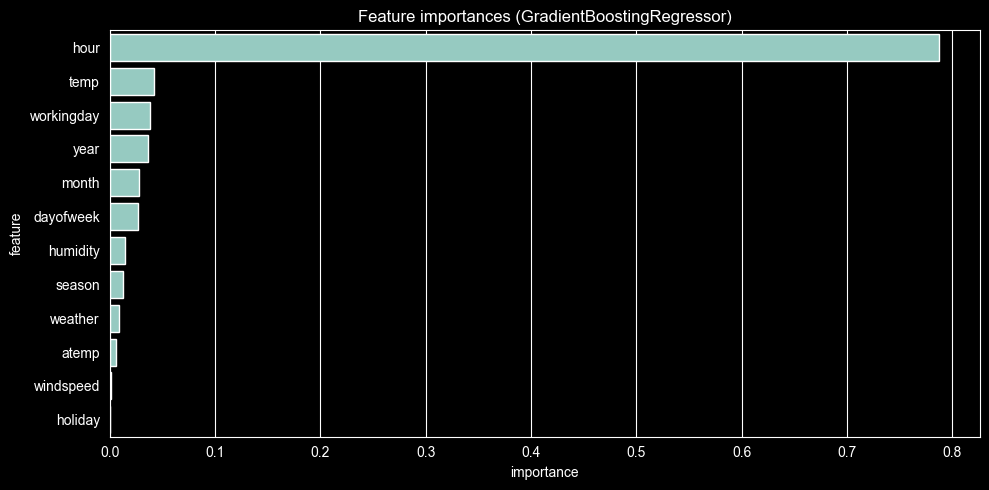

In [16]:
#importance of the features for the GradientBoostingRegressor
feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": gbr.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importances, x="importance", y="feature")
plt.title("Feature importances (GradientBoostingRegressor)")
plt.tight_layout()
plt.show()

Checking the results with deleting the lowest priority features

In [17]:
#Deleting most non-important values from RandomForest
rf.fit(X_train.drop(["windspeed", "holiday"], axis=1), y_train_log)
y_pred_rf = np.expm1(rf.predict(X_test.drop(["windspeed", "holiday"], axis=1)))
results.append(evaluate_model("RandomForest_cleaned", y_test, y_pred_rf))

In [18]:
#Deleting most non-important values from GradientBoostingRegressor
gbr.fit(X_train.drop(["windspeed", "holiday"], axis=1), y_train_log)
y_pred_gbr = np.expm1(gbr.predict(X_test.drop(["windspeed", "holiday"], axis=1)))
results.append(evaluate_model("GradientBoosting_cleaned", y_test, y_pred_gbr))

Final result

In [19]:
results_df = pd.DataFrame(results)
print(results_df)

                      model     RMSLE        RMSE         MAE
0          LinearRegression  1.010358  158.366369  104.209099
1              RandomForest  0.319148   49.366482   29.396461
2          GradientBoosting  0.371465   68.361313   41.150791
3      RandomForest_cleaned  0.317176   48.488266   28.957758
4  GradientBoosting_cleaned  0.372736   69.771740   42.250038
